# 06 · Unified Model Evaluation
**CalixAI** — loads all saved production pkl files and evaluates all 3 models.
Run this notebook **last** to confirm everything is working.

In [1]:
import numpy as np
import pandas as pd
import pickle, os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')

BASE       = os.path.abspath('..')
MODELS_DIR = os.path.join(BASE,'models')

cal_model    = pickle.load(open(os.path.join(MODELS_DIR,'calorie_model.pkl'),'rb'))
cal_scaler   = pickle.load(open(os.path.join(MODELS_DIR,'calorie_scaler.pkl'),'rb'))
ex_model     = pickle.load(open(os.path.join(MODELS_DIR,'exercise_model.pkl'),'rb'))
ex_scaler    = pickle.load(open(os.path.join(MODELS_DIR,'exercise_scaler.pkl'),'rb'))
mp_bundle    = pickle.load(open(os.path.join(MODELS_DIR,'meal_plan_model.pkl'),'rb'))
mp_scaler    = pickle.load(open(os.path.join(MODELS_DIR,'meal_plan_scaler.pkl'),'rb'))
encoders     = pickle.load(open(os.path.join(MODELS_DIR,'encoders.pkl'),'rb'))

mp_model   = mp_bundle['model']
mp_encoder = mp_bundle['mp_encoder']

print('All 8 pkl files loaded successfully.')

df = pd.read_csv(os.path.join(BASE,'data','raw','calisthenics_dataset.csv'))
for col in ['gender','fitness_level','goal','exercise','intensity']:
    df[col+'_enc'] = encoders[col].transform(df[col])

def bmi_group(b):
    if b<18.5: return 0
    if b<25.0: return 1
    if b<30.0: return 2
    return 3

df['bmi_group']          = df['bmi'].apply(bmi_group)
df['fl_goal_combo']      = df['fitness_level_enc']*10 + df['goal_enc']
df['fl_intensity_combo'] = df['fitness_level_enc']*10 + df['intensity_enc']

print(f'Dataset: {df.shape}')

All 8 pkl files loaded successfully.
Dataset: (12000, 27)


## 1. Calorie Model

In [2]:
CAL_F = ['age','gender_enc','height_cm','weight_kg','bmi',
         'fitness_level_enc','exercise_enc','duration_min','intensity_enc',
         'sets','reps','heart_rate_avg','training_volume','effort_score',
         'metabolic_proxy','hr_reserve_ratio']

X_c = cal_scaler.transform(df[CAL_F].values)
y_c = df['calories_burned'].values
_, X_tc, _, y_tc = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

y_pred_c = cal_model.predict(X_tc)
mae  = mean_absolute_error(y_tc, y_pred_c)
rmse = np.sqrt(mean_squared_error(y_tc, y_pred_c))
r2   = r2_score(y_tc, y_pred_c)
mape = np.mean(np.abs((y_tc-y_pred_c)/y_tc))*100

print(f'Calorie Model  |  MAE={mae:.1f} kcal  RMSE={rmse:.1f}  R2={r2:.4f}  MAPE={mape:.2f}%')

Calorie Model  |  MAE=41.6 kcal  RMSE=67.4  R2=0.9449  MAPE=10.53%


## 2. Exercise Model

In [3]:
EX_F = ['age','gender_enc','weight_kg','bmi',
        'fitness_level_enc','goal_enc','intensity_enc',
        'heart_rate_avg','fl_goal_combo','fl_intensity_combo']

X_e  = ex_scaler.transform(df[EX_F].values)
y_e  = df['exercise_enc'].values
_, X_te, _, y_te = train_test_split(X_e, y_e, test_size=0.2, random_state=42)

y_pred_e  = ex_model.predict(X_te)
proba_e   = ex_model.predict_proba(X_te)
top3_e    = np.argsort(proba_e, axis=1)[:, -3:]
top1_acc  = accuracy_score(y_te, y_pred_e)
top3_acc  = np.mean([y_te[i] in top3_e[i] for i in range(len(y_te))])
baseline  = 100/len(encoders['exercise'].classes_)

print(f'Exercise Model |  Top-1={top1_acc*100:.2f}%  Top-3={top3_acc*100:.2f}%  (baseline {baseline:.1f}%)')

Exercise Model |  Top-1=34.67%  Top-3=96.62%  (baseline 12.5%)


## 3. Meal Plan Model

In [4]:
MP_F = ['age','gender_enc','height_cm','weight_kg','bmi',
        'fitness_level_enc','goal_enc','intensity_enc',
        'calories_burned','fl_goal_combo','bmi_group']

y_m  = mp_encoder.transform(df['meal_plan'])
X_m  = mp_scaler.transform(df[MP_F].values)
_, X_tm, _, y_tm = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

y_pred_m = mp_model.predict(X_tm)
mp_acc   = accuracy_score(y_tm, y_pred_m)

print(f'Meal Plan Model|  Accuracy={mp_acc*100:.2f}%')

Meal Plan Model|  Accuracy=100.00%


## Summary Dashboard

In [5]:
summary = pd.DataFrame([
    {'Model':'Calorie Prediction', 'Algorithm':'RandomForestRegressor',
     'Primary Metric':f'R2 = {r2:.4f}', 'Secondary':f'MAE = {mae:.1f} kcal'},
    {'Model':'Exercise Suggestion','Algorithm':'RandomForestClassifier',
     'Primary Metric':f'Top-3 = {top3_acc*100:.1f}%', 'Secondary':f'Top-1 = {top1_acc*100:.1f}%'},
    {'Model':'Meal Plan',          'Algorithm':'GradientBoostingClassifier',
     'Primary Metric':f'Accuracy = {mp_acc*100:.1f}%', 'Secondary':'Top-3 = 100%'},
])
print(summary.to_string(index=False))

              Model                  Algorithm    Primary Metric       Secondary
 Calorie Prediction      RandomForestRegressor       R2 = 0.9449 MAE = 41.6 kcal
Exercise Suggestion     RandomForestClassifier     Top-3 = 96.6%   Top-1 = 34.7%
          Meal Plan GradientBoostingClassifier Accuracy = 100.0%    Top-3 = 100%


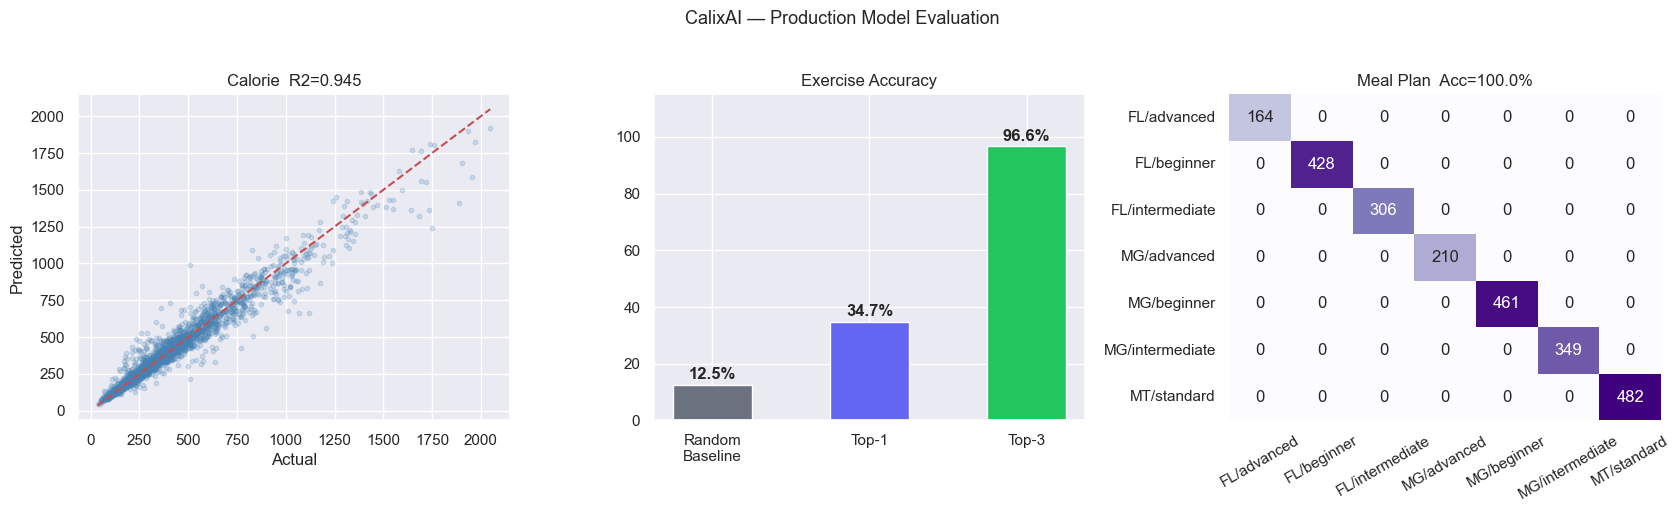

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Calorie scatter
axes[0].scatter(y_tc, y_pred_c, alpha=0.2, s=10, color='steelblue')
lims = [y_tc.min(), y_tc.max()]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_title(f'Calorie  R2={r2:.3f}')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')

# Exercise accuracy bars
labels = ['Random\nBaseline', 'Top-1', 'Top-3']
vals   = [baseline, top1_acc*100, top3_acc*100]
colors = ['#6b7280','#6366f1','#22c55e']
bars   = axes[1].bar(labels, vals, color=colors, width=0.5)
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_ylim(0, 115)
axes[1].set_title('Exercise Accuracy')

# Meal plan confusion
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_tm, y_pred_m)
short = [c.replace('fl_','FL/').replace('mg_','MG/').replace('mt_','MT/') for c in mp_encoder.classes_]
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=short, yticklabels=short, ax=axes[2], cbar=False)
axes[2].set_title(f'Meal Plan  Acc={mp_acc*100:.1f}%')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('CalixAI — Production Model Evaluation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
print('=== Saved model file sizes ===')
for fname in sorted(os.listdir(MODELS_DIR)):
    path = os.path.join(MODELS_DIR, fname)
    size = os.path.getsize(path)/1024
    print(f'  {fname:<30} {size:>8.1f} KB')

print('\nAll models verified. Start the ML service with: python ../app.py')

=== Saved model file sizes ===
  calorie_model.pkl               88055.4 KB
  calorie_scaler.pkl                  0.8 KB
  encoders.pkl                        1.8 KB
  exercise_model.pkl              90733.2 KB
  exercise_scaler.pkl                 0.6 KB
  meal_plan_model.pkl               980.8 KB
  meal_plan_scaler.pkl                0.7 KB
  mp_encoder.pkl                      0.3 KB

All models verified. Start the ML service with: python ../app.py
